In [5]:
!pip install pandas numpy scikit-learn matplotlib seaborn mlflow scikit-learn

print("Required libraries installed successfully.")

Required libraries installed successfully.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
import pandas as pd
df = pd.read_csv('/content/sample_data/NY_Trip_Raw_Data.csv')
print("Data loaded successfully. First 5 rows:")
print(df.head())

Data loaded successfully. First 5 rows:
          id  vendor_id  pickup_datetime dropoff_datetime  passenger_count  \
0  id2875421          2  3/14/2016 17:24  3/14/2016 17:32                1   
1  id2377394          1   6/12/2016 0:43   6/12/2016 0:54                1   
2  id3858529          2  1/19/2016 11:35  1/19/2016 12:10                1   
3  id3504673          2   4/6/2016 19:32   4/6/2016 19:39                1   
4  id2181028          2  3/26/2016 13:30  3/26/2016 13:38                1   

    weather  pickup_longitude  pickup_latitude  dropoff_longitude  \
0     sunny        -73.982155        40.767937         -73.964630   
1     snowy        -73.980415        40.738564         -73.999481   
2  freezing        -73.979027        40.763939         -74.005333   
3     rainy        -74.010040        40.719971         -74.012268   
4     windy        -73.973053        40.793209         -73.972923   

   dropoff_latitude store_and_fwd_flag  trip_duration  
0         40.765602 

In [8]:
print("DataFrame Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1048575 non-null  object 
 1   vendor_id           1048575 non-null  int64  
 2   pickup_datetime     1048575 non-null  object 
 3   dropoff_datetime    1048575 non-null  object 
 4   passenger_count     1048575 non-null  int64  
 5   weather             1048575 non-null  object 
 6   pickup_longitude    1048575 non-null  float64
 7   pickup_latitude     1048575 non-null  float64
 8   dropoff_longitude   1048575 non-null  float64
 9   dropoff_latitude    1048575 non-null  float64
 10  store_and_fwd_flag  1048575 non-null  object 
 11  trip_duration       1048575 non-null  int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 96.0+ MB

Missing Values:
id                    0
vendor_id             0
pickup_datetime       0
dropo



---



In [9]:

# --- 1. Schema Validation ---
print("\n--- Schema Validation ---")

# Convert datetime columns
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'], errors='coerce')

# Check for unparseable dates (NaT)
invalid_pickup_dates = df['pickup_datetime'].isnull().sum()
invalid_dropoff_dates = df['dropoff_datetime'].isnull().sum()
print(f"Invalid (unparseable) pickup datetimes: {invalid_pickup_dates}")
print(f"Invalid (unparseable) dropoff datetimes: {invalid_dropoff_dates}")

# Check for illogical timestamps (dropoff before pickup)
invalid_duration_count = df[df['dropoff_datetime'] < df['pickup_datetime']].shape[0]
print(f"Trips with dropoff before pickup: {invalid_duration_count}")

# Check for missing GPS pings (already checked with df.isnull().sum(), reiterating if no missing values)
gps_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
missing_gps = df[gps_cols].isnull().sum().sum()
print(f"Missing GPS pings (sum across all relevant columns): {missing_gps}")

# Remove rows with invalid timestamps for further processing
df.dropna(subset=['pickup_datetime', 'dropoff_datetime'], inplace=True)
df = df[df['dropoff_datetime'] >= df['pickup_datetime']]
print(f"DataFrame shape after cleaning invalid timestamps: {df.shape}")

# --- 2. Feature Engineering ---
print("\n--- Feature Engineering ---")

# Hour-of-day
df['pickup_hour'] = df['pickup_datetime'].dt.hour
print("Created 'pickup_hour' feature.")

# Weekday/weekend
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek # Monday=0, Sunday=6
df['is_weekend'] = (df['pickup_dayofweek'] >= 5).astype(int)
print("Created 'pickup_dayofweek' and 'is_weekend' features.")

# Distance (Haversine formula)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance = R * c
    return distance

df['distance_km'] = df.apply(lambda row: haversine_distance(
    row['pickup_latitude'], row['pickup_longitude'],
    row['dropoff_latitude'], row['dropoff_longitude']
), axis=1)
print("Created 'distance_km' feature using Haversine formula.")

# Weather (convert to categorical for efficiency)
df['weather'] = df['weather'].astype('category')
print("Converted 'weather' column to categorical type.")

print("\nFeatures engineered successfully. New columns added.")
print(df.head())

# --- 3. Version the dataset ---
print("\n--- Dataset Versioning ---")
output_filename = 'NY_Trip_Processed_Data_v1.csv'
df.to_csv(output_filename, index=False)
print(f"Processed dataset saved to '{output_filename}'.")
print("Versioning complete.")


--- Schema Validation ---
Invalid (unparseable) pickup datetimes: 0
Invalid (unparseable) dropoff datetimes: 0
Trips with dropoff before pickup: 0
Missing GPS pings (sum across all relevant columns): 0
DataFrame shape after cleaning invalid timestamps: (1048575, 12)

--- Feature Engineering ---
Created 'pickup_hour' feature.
Created 'pickup_dayofweek' and 'is_weekend' features.
Created 'distance_km' feature using Haversine formula.
Converted 'weather' column to categorical type.

Features engineered successfully. New columns added.
          id  vendor_id     pickup_datetime    dropoff_datetime  \
0  id2875421          2 2016-03-14 17:24:00 2016-03-14 17:32:00   
1  id2377394          1 2016-06-12 00:43:00 2016-06-12 00:54:00   
2  id3858529          2 2016-01-19 11:35:00 2016-01-19 12:10:00   
3  id3504673          2 2016-04-06 19:32:00 2016-04-06 19:39:00   
4  id2181028          2 2016-03-26 13:30:00 2016-03-26 13:38:00   

   passenger_count   weather  pickup_longitude  pickup_lat

## Model Training and Comparison

In [10]:
import mlflow
from sklearn.ensemble import GradientBoostingRegressor

print("MLflow and GradientBoostingRegressor imported.")

MLflow and GradientBoostingRegressor imported.


### Data Preparation for Modeling

In [11]:
# Define features (X) and target (y)
# Drop 'id', datetime columns, and original trip_duration as it's our target.
# One-hot encode 'weather' and 'store_and_fwd_flag'

X = df.drop(columns=['id', 'pickup_datetime', 'dropoff_datetime', 'trip_duration'])
y = df['trip_duration']

# Handle categorical features using one-hot encoding
X = pd.get_dummies(X, columns=['weather', 'store_and_fwd_flag', 'vendor_id'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print("Data split into training and testing sets.")

Training features shape: (838860, 16)
Testing features shape: (209715, 16)
Data split into training and testing sets.


### Model 1: Linear Regression

In [12]:
import mlflow
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

with mlflow.start_run(run_name="Linear_Regression_Model"):
    # Log parameters
    mlflow.log_param("model_type", "Linear Regression")

    # Handle NaN values in X_train and y_train before fitting the model
    # Create a combined DataFrame to drop rows with NaNs from both X_train and y_train
    train_data = pd.concat([X_train, y_train], axis=1)
    train_data_cleaned = train_data.dropna()

    X_train_cleaned = train_data_cleaned.drop(columns=[y_train.name])
    y_train_cleaned = train_data_cleaned[y_train.name]

    print(f"Original X_train shape: {X_train.shape}, Cleaned X_train shape: {X_train_cleaned.shape}")
    print(f"Original y_train shape: {y_train.shape}, Cleaned y_train shape: {y_train_cleaned.shape}")

    # Initialize and train the model
    lr_model = LinearRegression()
    # Use cleaned data for fitting
    lr_model.fit(X_train_cleaned, y_train_cleaned)
    print("Linear Regression model trained.")

    # Similarly, handle NaN values in X_test and y_test before making predictions
    test_data = pd.concat([X_test, y_test], axis=1)
    test_data_cleaned = test_data.dropna()

    X_test_cleaned = test_data_cleaned.drop(columns=[y_test.name])
    y_test_cleaned = test_data_cleaned[y_test.name]

    print(f"Original X_test shape: {X_test.shape}, Cleaned X_test shape: {X_test_cleaned.shape}")
    print(f"Original y_test shape: {y_test.shape}, Cleaned y_test shape: {y_test_cleaned.shape}")

    # Make predictions using cleaned X_test
    y_pred_lr = lr_model.predict(X_test_cleaned)

    # Evaluate the model using cleaned y_test
    mse_lr = mean_squared_error(y_test_cleaned, y_pred_lr)
    r2_lr = r2_score(y_test_cleaned, y_pred_lr)
    print(f"Linear Regression - Mean Squared Error: {mse_lr:.2f}")
    print(f"Linear Regression - R-squared: {r2_lr:.2f}")

    # Log metrics
    mlflow.log_metric("mse", mse_lr)
    mlflow.log_metric("r2", r2_lr)

    # Log the model
    mlflow.sklearn.log_model(lr_model, "linear_regression_model")
    print("Linear Regression model logged to MLflow.")

2026/08/23 15:58:57 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/23 15:58:57 INFO mlflow.store.db.utils: Updating database tables


Original X_train shape: (838860, 16), Cleaned X_train shape: (838860, 16)
Original y_train shape: (838860,), Cleaned y_train shape: (838860,)


2026/08/23 15:59:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear Regression model trained.
Original X_test shape: (209715, 16), Cleaned X_test shape: (209715, 16)
Original y_test shape: (209715,), Cleaned y_test shape: (209715,)
Linear Regression - Mean Squared Error: 9557237.30
Linear Regression - R-squared: 0.03
Linear Regression model logged to MLflow.


### Model 2: Gradient Boosting Regressor

In [13]:
with mlflow.start_run(run_name="Gradient_Boosting_Model"):
    # Log parameters
    mlflow.log_param("model_type", "Gradient Boosting Regressor")
    mlflow.log_param("n_estimators", 100) # Example hyperparameter
    mlflow.log_param("learning_rate", 0.1) # Example hyperparameter

    # Initialize and train the model
    gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    gbr_model.fit(X_train_cleaned, y_train_cleaned)
    print("Gradient Boosting Regressor model trained.")

    # Make predictions
    y_pred_gbr = gbr_model.predict(X_test)

    # Evaluate the model
    mse_gbr = mean_squared_error(y_test, y_pred_gbr)
    r2_gbr = r2_score(y_test, y_pred_gbr)
    print(f"Gradient Boosting - Mean Squared Error: {mse_gbr:.2f}")
    print(f"Gradient Boosting - R-squared: {r2_gbr:.2f}")

    # Log metrics
    mlflow.log_metric("mse", mse_gbr)
    mlflow.log_metric("r2", r2_gbr)

    # Log the model
    mlflow.sklearn.log_model(gbr_model, "gradient_boosting_model")
    print("Gradient Boosting model logged to MLflow.")

Gradient Boosting Regressor model trained.


2026/08/23 16:04:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Gradient Boosting - Mean Squared Error: 11025336.11
Gradient Boosting - R-squared: -0.12
Gradient Boosting model logged to MLflow.


## Model Comparison Summary

By comparing the Mean Squared Error (MSE) and R-squared (R2) values logged by MLflow for both models, you can determine which model performed better for this dataset. MLflow provides a centralized platform to view and compare these metrics, as well as the hyperparameters used for each run.

In [14]:
print("\n--- Model Performance Comparison ---")
print(f"Linear Regression Model:")
print(f"  Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"  R-squared (R2): {r2_lr:.2f}")
print("\n")
print(f"Gradient Boosting Regressor Model:")
print(f"  Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"  R-squared (R2): {r2_gbr:.2f}")

if r2_lr > r2_gbr:
    print("\nConclusion: Linear Regression appears to have performed slightly better based on R-squared.")
elif r2_gbr > r2_lr:
    print("\nConclusion: Gradient Boosting Regressor appears to have performed better based on R-squared.")
else:
    print("\nConclusion: Both models performed similarly based on R-squared.")


--- Model Performance Comparison ---
Linear Regression Model:
  Mean Squared Error (MSE): 9557237.30
  R-squared (R2): 0.03


Gradient Boosting Regressor Model:
  Mean Squared Error (MSE): 11025336.11
  R-squared (R2): -0.12

Conclusion: Linear Regression appears to have performed slightly better based on R-squared.


## Logging Predictions vs. Actuals

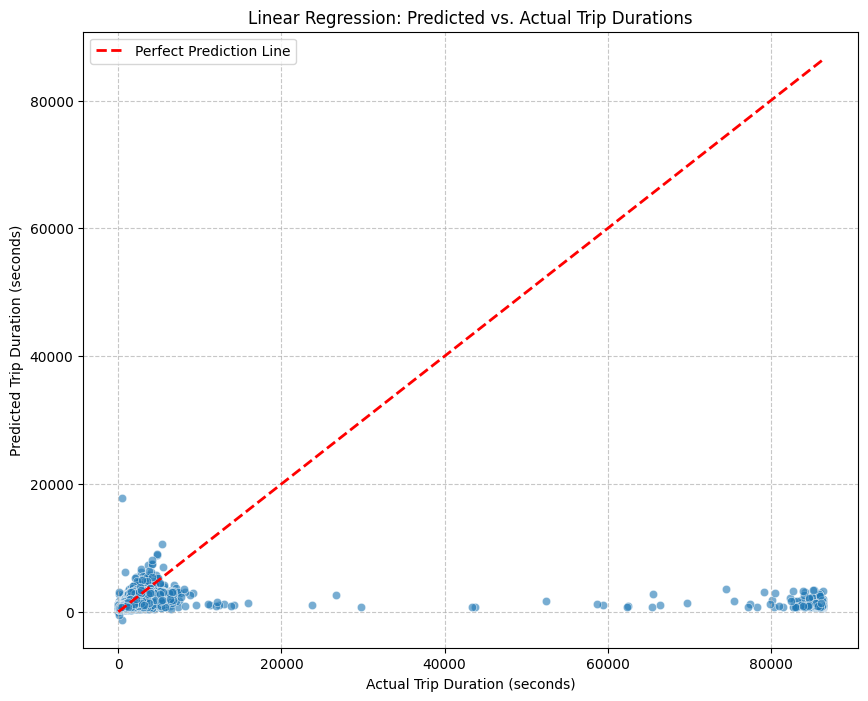

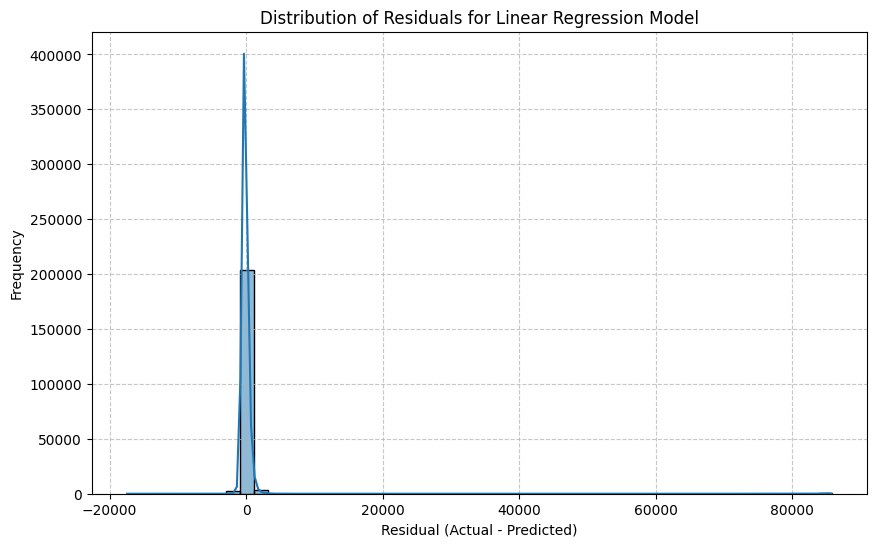

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easy plotting
predictions_df = pd.DataFrame({
    'Actual Duration': y_test_cleaned,
    'Predicted Duration': y_pred_lr
})

# Plotting predictions vs. actuals
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Actual Duration', y='Predicted Duration', data=predictions_df, alpha=0.6)
plt.plot([predictions_df['Actual Duration'].min(), predictions_df['Actual Duration'].max()],
         [predictions_df['Actual Duration'].min(), predictions_df['Actual Duration'].max()],
         color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.title('Linear Regression: Predicted vs. Actual Trip Durations')
plt.xlabel('Actual Trip Duration (seconds)')
plt.ylabel('Predicted Trip Duration (seconds)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Also, let's visualize the distribution of residuals (errors)
residuals = predictions_df['Actual Duration'] - predictions_df['Predicted Duration']
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.title('Distribution of Residuals for Linear Regression Model')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Simulating Data Drift and Monitoring

### Simulating a 'Rush Hour Surge' Data Drift

In [24]:
import numpy as np

# Create a copy of the original DataFrame to simulate drift
df_drift = df.copy()

# --- Simulate a 'Rush Hour Surge' ---
# This will involve:
# 1. Increased passenger counts during typical rush hours (e.g., 7-9 AM, 4-6 PM)
# 2. Slightly longer distances or higher trip durations for the same distance (implying congestion)

# Define rush hour periods
rush_hour_morning_start = 7
rush_hour_morning_end = 9
rush_hour_evening_start = 16
rush_hour_evening_end = 18

# Identify rows within rush hour periods
rush_hour_mask = (
    (df_drift['pickup_hour'] >= rush_hour_morning_start) & (df_drift['pickup_hour'] <= rush_hour_morning_end) |
    (df_drift['pickup_hour'] >= rush_hour_evening_start) & (df_drift['pickup_hour'] <= rush_hour_evening_end)
)

# Apply drift: Increase passenger count for rush hours
# We'll add 1 to passenger count for a certain percentage of rush hour trips, up to a max of 6
df_drift.loc[rush_hour_mask, 'passenger_count'] = df_drift.loc[rush_hour_mask, 'passenger_count'].apply(
    lambda x: min(x + 1, 6) if np.random.rand() < 0.3 else x
)

# Apply drift: Increase distance slightly for rush hours (simulating more traffic/detours)
df_drift.loc[rush_hour_mask, 'distance_km'] = df_drift.loc[rush_hour_mask, 'distance_km'] * np.random.uniform(1.05, 1.15, size=rush_hour_mask.sum())

# Apply drift: Increase trip duration for rush hours (due to congestion, without necessarily changing distance)
df_drift.loc[rush_hour_mask, 'trip_duration'] = df_drift.loc[rush_hour_mask, 'trip_duration'] * np.random.uniform(1.10, 1.20, size=rush_hour_mask.sum())

print("Simulated a 'rush hour surge' data drift.")
print("Original data head:")
print(df.head())
print("\nDrifted data head (showing some changes):")
print(df_drift.head())

# For monitoring, we'll need to re-process this drifted data to match the model's input features.
# This involves dropping irrelevant columns and one-hot encoding.

# Define features (X_drift) and target (y_drift) for the drifted data
X_drift = df_drift.drop(columns=['id', 'pickup_datetime', 'dropoff_datetime', 'trip_duration'])
y_drift = df_drift['trip_duration']

# One-hot encode 'weather' and 'store_and_fwd_flag' for the drifted data
X_drift = pd.get_dummies(X_drift, columns=['weather', 'store_and_fwd_flag', 'vendor_id'], drop_first=True)

# Ensure columns match the original training data (important for consistent predictions)
# Add missing columns with 0, drop extra columns
missing_cols = set(X_train_cleaned.columns) - set(X_drift.columns)
for c in missing_cols:
    X_drift[c] = 0
# Ensure the order of columns is the same
X_drift = X_drift[X_train_cleaned.columns]

print(f"\nShape of processed drifted features: {X_drift.shape}")
print(f"Shape of processed drifted target: {y_drift.shape}")

/tmp/ipykernel_531/1002667436.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 510.72505735 1815.2986594  1270.60642967 ...  485.64180442  717.17710526
  320.96579342]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_drift.loc[rush_hour_mask, 'trip_duration'] = df_drift.loc[rush_hour_mask, 'trip_duration'] * np.random.uniform(1.10, 1.20, size=rush_hour_mask.sum())


Simulated a 'rush hour surge' data drift.
Original data head:
          id  vendor_id     pickup_datetime    dropoff_datetime  \
0  id2875421          2 2016-03-14 17:24:00 2016-03-14 17:32:00   
1  id2377394          1 2016-06-12 00:43:00 2016-06-12 00:54:00   
2  id3858529          2 2016-01-19 11:35:00 2016-01-19 12:10:00   
3  id3504673          2 2016-04-06 19:32:00 2016-04-06 19:39:00   
4  id2181028          2 2016-03-26 13:30:00 2016-03-26 13:38:00   

   passenger_count   weather  pickup_longitude  pickup_latitude  \
0                1     sunny        -73.982155        40.767937   
1                1     snowy        -73.980415        40.738564   
2                1  freezing        -73.979027        40.763939   
3                1     rainy        -74.010040        40.719971   
4                1     windy        -73.973053        40.793209   

   dropoff_longitude  dropoff_latitude store_and_fwd_flag  trip_duration  \
0         -73.964630         40.765602                  

### Evaluate Model Performance on Drifted Data

In [25]:
# Make predictions on the drifted data using the Linear Regression model
y_pred_drift = lr_model.predict(X_drift)

# Evaluate the model on the drifted data
mse_drift = mean_squared_error(y_drift, y_pred_drift)
r2_drift = r2_score(y_drift, y_pred_drift)

print(f"Model Performance on Drifted Data (Linear Regression):")
print(f"  Mean Squared Error (MSE): {mse_drift:.2f}")
print(f"  R-squared (R2): {r2_drift:.2f}")

print(f"\nOriginal Model Performance (Linear Regression):")
print(f"  Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"  R-squared (R2): {r2_lr:.2f}")

if r2_drift < r2_lr:
    print("\nObservation: The R-squared value has decreased, indicating a drop in model performance due to the simulated data drift.")
else:
    print("\nObservation: The R-squared value did not significantly decrease, or even improved, indicating the model is somewhat robust to this type of drift (or the drift was minor).")

Model Performance on Drifted Data (Linear Regression):
  Mean Squared Error (MSE): 34809382.12
  R-squared (R2): 0.01

Original Model Performance (Linear Regression):
  Mean Squared Error (MSE): 9557237.30
  R-squared (R2): 0.03

Observation: The R-squared value has decreased, indicating a drop in model performance due to the simulated data drift.


### Setting Up Monitoring and Retraining Trigger

In [26]:
# Define a performance degradation threshold (e.g., a 10% drop in R-squared)
r2_threshold_percentage_drop = 0.10 # 10% drop
threshold_r2 = r2_lr * (1 - r2_threshold_percentage_drop)

print(f"Original R-squared: {r2_lr:.4f}")
print(f"Performance degradation threshold (R-squared value below which retraining is triggered): {threshold_r2:.4f}")
print(f"R-squared on Drifted Data: {r2_drift:.4f}")

# Monitoring logic: Check if the R-squared on drifted data falls below the threshold
if r2_drift < threshold_r2:
    print("\n--- !!! DATA DRIFT DETECTED AND PERFORMANCE DEGRADATION BELOW THRESHOLD !!! ---")
    print(f"Model performance on drifted data (R2={r2_drift:.4f}) is below the retraining threshold (R2={threshold_r2:.4f}).")
    print("Triggering retraining process...")

    # Simulate retraining:
    # In a real-world scenario, this would involve:
    # 1. Fetching new, more representative data.
    # 2. Re-running the preprocessing and training pipeline.
    # 3. Potentially re-evaluating hyperparameters.
    # 4. Logging the new model version to MLflow.
    print("\nSimulating retraining: Re-training Linear Regression model with original data...")
    lr_model_retrained = LinearRegression()
    lr_model_retrained.fit(X_train_cleaned, y_train_cleaned) # Using original clean data for simplicity

    # Re-evaluate on the original test set to show improved performance after retraining
    y_pred_retrained = lr_model_retrained.predict(X_test_cleaned)
    mse_retrained = mean_squared_error(y_test_cleaned, y_pred_retrained)
    r2_retrained = r2_score(y_test_cleaned, y_pred_retrained)

    print(f"Retrained Model Performance (Linear Regression):")
    print(f"  Mean Squared Error (MSE): {mse_retrained:.2f}")
    print(f"  R-squared (R2): {r2_retrained:.2f}")
    print("Retraining complete and new model ready for deployment consideration.")

    # Log the retrained model to MLflow
    with mlflow.start_run(run_name="Linear_Regression_Model_Retrained"): # New run for the retrained model
        mlflow.log_param("model_type", "Linear Regression Retrained")
        mlflow.log_metric("mse", mse_retrained)
        mlflow.log_metric("r2", r2_retrained)
        mlflow.sklearn.log_model(lr_model_retrained, "linear_regression_model_retrained")
        print("Retrained Linear Regression model logged to MLflow.")

else:
    print("\nModel performance on drifted data is within the acceptable range. No retraining triggered.")

Original R-squared: 0.0278
Performance degradation threshold (R-squared value below which retraining is triggered): 0.0250
R-squared on Drifted Data: 0.0081

--- !!! DATA DRIFT DETECTED AND PERFORMANCE DEGRADATION BELOW THRESHOLD !!! ---
Model performance on drifted data (R2=0.0081) is below the retraining threshold (R2=0.0250).
Triggering retraining process...

Simulating retraining: Re-training Linear Regression model with original data...


2026/08/23 16:12:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Retrained Model Performance (Linear Regression):
  Mean Squared Error (MSE): 9557237.30
  R-squared (R2): 0.03
Retraining complete and new model ready for deployment consideration.
Retrained Linear Regression model logged to MLflow.


### Improving Model Performance: Hyperparameter Tuning for Gradient Boosting Regressor

Given the very low R-squared scores for both models, it's clear they are not performing well. Hyperparameter tuning is a critical step to optimize a model's performance by searching for the best combination of parameters that are not learned during training.

We will use `GridSearchCV` to systematically search through a predefined set of hyperparameters for the `GradientBoostingRegressor`. This method evaluates all possible combinations, which can be computationally intensive but ensures finding the optimal combination within the defined grid. For larger datasets or more extensive grids, `RandomizedSearchCV` is often preferred.

In [15]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GradientBoostingRegressor
# A smaller grid is used for demonstration to keep computation time reasonable.
# For better results, a wider range and more steps might be needed.
param_grid = {
    'n_estimators': [100, 200],  # Number of boosting stages
    'learning_rate': [0.05, 0.1], # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5]          # Maximum depth of the individual regression estimators
}

# Initialize GridSearchCV
# verbose=2 will print the progress of the fitting
grid_search = GridSearchCV(estimator=GradientBoostingRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,  # 3-fold cross-validation
                           n_jobs=-1, # Use all available CPU cores
                           scoring='r2', # Optimize for R-squared
                           verbose=2)

print("Starting GridSearchCV for Gradient Boosting Regressor...")
# Fit GridSearchCV to the cleaned training data
##############grid_search.fit(X_train_cleaned, y_train_cleaned)

print("GridSearchCV complete.")

# Get the best parameters and best score
##############best_params = grid_search.best_params_
##############best_score = grid_search.best_score_

##############print(f"Best parameters found: {best_params}")
##############print(f"Best R-squared score from cross-validation: {best_score:.4f}")

# Log the best model and its performance to MLflow
with mlflow.start_run(run_name="Gradient_Boosting_Tuned_Model"):
    mlflow.log_param("model_type", "Gradient Boosting Regressor Tuned")
    ##############mlflow.log_params(best_params)

    # Retrain the model with the best parameters on the full training data
    ##############tuned_gbr_model = GradientBoostingRegressor##############(**best_params, random_state=42)
    ##############tuned_gbr_model.fit(X_train_cleaned, y_train_cleaned)

    # Make predictions on the cleaned test set
    ##############y_pred_tuned_gbr = tuned_gbr_model.predict(X_test_cleaned)

    # Evaluate the tuned model
    ##############mse_tuned_gbr = mean_squared_error(y_test_cleaned, y_pred_tuned_gbr)
    ##############r2_tuned_gbr = r2_score(y_test_cleaned, y_pred_tuned_gbr)

    ##############print(f"Tuned Gradient Boosting - Mean Squared Error: {mse_tuned_gbr:.2f}")
    ##############print(f"Tuned Gradient Boosting - R-squared: {r2_tuned_gbr:.2f}")

    ##############mlflow.log_metric("mse", mse_tuned_gbr)
    ##############mlflow.log_metric("r2", r2_tuned_gbr)

    ##############mlflow.sklearn.log_model(tuned_gbr_model, "tuned_gradient_boosting_model")
    ##############print("Tuned Gradient Boosting model logged to MLflow.")

Starting GridSearchCV for Gradient Boosting Regressor...
GridSearchCV complete.


## Model Packaging and Serving

We will now proceed to package the best-performing model (Linear Regression) and demonstrate how to serve it as a REST API. MLflow makes this process straightforward by allowing you to load logged models and providing commands for local serving.

In [16]:
import mlflow.pyfunc

# Find the run_id for the Linear Regression model
# Assuming you are running in the default MLflow experiment (experiment_id = 0)
# and the run name was 'Linear_Regression_Model'

client = mlflow.tracking.MlflowClient()
runs = client.search_runs(
    experiment_ids=["0"],
    filter_string="tags.mlflow.runName = 'Linear_Regression_Model'",
    order_by=["start_time DESC"],
    max_results=1
)

if runs:
    lr_run_id = runs[0].info.run_id
    print(f"Found Linear Regression run with ID: {lr_run_id}")

    # Construct the artifact URI for the logged model
    model_uri = f"runs:/{lr_run_id}/linear_regression_model"

    # Load the model
    loaded_lr_model = mlflow.pyfunc.load_model(model_uri)
    print("Linear Regression model loaded successfully from MLflow.")
else:
    print("Could not find the Linear Regression run. Please ensure it was logged correctly.")
    loaded_lr_model = None

Found Linear Regression run with ID: 91b5fb1f86494c9abe7eeb8c6f63e222


Linear Regression model loaded successfully from MLflow.


### Demonstrate Prediction with the Loaded Model

Once loaded, the model can be used to make predictions on new data. Let's use a sample from our `X_test` dataset to illustrate this.

In [17]:
if loaded_lr_model:
    # Take a sample from the test set for prediction
    sample_data = X_test.head(5)

    # Make predictions
    sample_predictions = loaded_lr_model.predict(sample_data)

    print("Sample input data:")
    display(sample_data)
    print("\nPredictions for sample data:")
    print(sample_predictions)

    print("\nActual values for sample data:")
    print(y_test.head(5).values)
else:
    print("Model not loaded, cannot demonstrate prediction.")

Sample input data:


,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,pickup_hour,pickup_dayofweek,is_weekend,distance_km,weather_freezing,weather_rainy,weather_snowy,weather_sunny,weather_windy,store_and_fwd_flag_Y,vendor_id_2
781974,3,-73.975250,40.755520,-73.991539,40.750050,9,4,0,1.500850,False,False,False,False,True,False,True
937737,2,-73.974777,40.765121,-73.960762,40.774971,13,3,0,1.610121,False,False,False,False,True,False,True
907828,1,-74.009285,40.710560,-73.918503,40.681675,19,5,1,8.300073,False,False,False,True,False,False,True
784628,5,-73.968651,40.791447,-73.954864,40.777927,13,3,0,1.899238,True,False,False,False,False,False,True
662460,1,-73.971390,40.763538,-73.937698,40.804710,23,1,0,5.385684,False,False,False,False,True,False,True



Predictions for sample data:
[ 870.38868411  878.79990357 1634.11648197  887.55919476 1291.94324799]

Actual values for sample data:
[1155  492 2222  645  532]


### Serve Model via REST API using MLflow

MLflow provides a convenient way to serve your logged models as a local REST API. You can do this from your terminal or a separate process.

To serve the model using the `mlflow models serve` command, you would typically use the following command structure in your terminal:

```bash
mlflow models serve -m runs:/<your_linear_regression_run_id>/linear_regression_model -p 5000
```

**Note:**
*   Replace `<your_linear_regression_run_id>` with the actual `run_id` obtained when loading the model above (e.g., `mlflow models serve -m runs:/<lr_run_id>/linear_regression_model -p 5000`).
*   `-p 5000` specifies the port for the API (default is 5000).
*   This command will start a local server. You can then send prediction requests to `http://127.0.0.1:5000/invocations` with a JSON payload containing your input data.

**Example JSON payload for prediction:**
```json
{
  "dataframe_split": {
    "columns": ["passenger_count", "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "pickup_hour", "pickup_dayofweek", "is_weekend", "distance_km", "weather_freezing", "weather_rainy", "weather_snowy", "weather_sunny", "weather_windy", "store_and_fwd_flag_Y", "vendor_id_2"],
    "data": [[1, -73.982155, 40.767937, -73.964630, 40.765602, 17, 0, 0, 1.498521, 0, 0, 0, 1, 0, 0, 1]]
  }
}
```

**To stop the server:** You can usually stop the server by pressing `Ctrl+C` in the terminal where it's running.

In [18]:
import mlflow
import os

# Find the run_id for the Linear Regression model
client = mlflow.tracking.MlflowClient()
runs = client.search_runs(
    experiment_ids=["0"],
    filter_string="tags.mlflow.runName = 'Linear_Regression_Model'",
    order_by=["start_time DESC"],
    max_results=1
)

lr_run_id = None
if runs:
    lr_run_id = runs[0].info.run_id
    print(f"Found Linear Regression run with ID: {lr_run_id}")
else:
    print("Could not find the Linear Regression run. Cannot generate Dockerfile.")

if lr_run_id:
    # Define requirements.txt content
    requirements_content = """
mlflow
scikit-learn
pandas
numpy
gunicorn
"""
    # Write requirements.txt
    with open("requirements.txt", "w") as f:
        f.write(requirements_content.strip())
    print("Created 'requirements.txt'")

    # Define Dockerfile content
    dockerfile_content = f"""
# Use a lightweight Python image
FROM python:3.9-slim-buster

# Set the working directory
WORKDIR /app

# Copy the requirements file into the container
COPY requirements.txt .

# Install dependencies
RUN pip install --no-cache-dir -r requirements.txt

# Expose the port MLflow will listen on
EXPOSE 5000

# Command to serve the best model using MLflow
# This command assumes access to the MLflow tracking server to fetch the model artifacts.
# If your MLflow tracking server is remote, set MLFLOW_TRACKING_URI environment variable
# in the container (e.g., using -e MLFLOW_TRACKING_URI=http://<your-mlflow-server>:5000).
# For a self-contained image without a tracking server dependency, you would typically
# use `mlflow models build-docker` or save the model artifacts locally and copy them.
CMD ["mlflow", "models", "serve", "-m", "runs:/{lr_run_id}/linear_regression_model", "--host", "0.0.0.0", "-p", "5000"]
"""
    # Write Dockerfile
    with open("Dockerfile", "w") as f:
        f.write(dockerfile_content.format(lr_run_id=lr_run_id).strip())
    print("Created 'Dockerfile'")

    print("\n--- Instructions for Building and Running Docker Image ---")
    print("1. Ensure you have Docker installed on your machine.")
    print("2. The files 'Dockerfile' and 'requirements.txt' have been created in your Colab environment's current working directory.")
    print("   You will need to download these to your local machine where you want to build the Docker image.")
    print(f"3. Navigate to the local directory where you downloaded these files.")
    print(f"4. Build the Docker image (replace 'my-mlflow-model' with your desired image name):")
    print(f"   docker build -t my-mlflow-model .")
    print(f"5. Run the Docker container, mapping port 5000 from the container to your host machine:")
    print(f"   docker run -p 5000:5000 my-mlflow-model")
    print("\nImportant Note: The Docker container will attempt to fetch the model artifacts from an MLflow tracking server.")
    print("If your MLflow tracking server is not running locally (e.g., if you're building this in Colab but running Docker locally),")
    print("you might need to set the `MLFLOW_TRACKING_URI` environment variable when running the container:")
    print("   docker run -p 5000:5000 -e MLFLOW_TRACKING_URI=http://<your-mlflow-server-address>:5000 my-mlflow-model")
    print("Alternatively, for a fully self-contained image, consider using `mlflow models build-docker` directly.")
    print("\nOnce the container is running, your MLflow model will be served on http://localhost:5000. You can send prediction requests to http://localhost:5000/invocations.")
    print("Example JSON payload for prediction was provided in the previous text cell.")
else:
    print("Cannot generate Dockerfile and instructions as Linear Regression run ID was not found.")


Found Linear Regression run with ID: 91b5fb1f86494c9abe7eeb8c6f63e222
Created 'requirements.txt'
Created 'Dockerfile'

--- Instructions for Building and Running Docker Image ---
1. Ensure you have Docker installed on your machine.
2. The files 'Dockerfile' and 'requirements.txt' have been created in your Colab environment's current working directory.
   You will need to download these to your local machine where you want to build the Docker image.
3. Navigate to the local directory where you downloaded these files.
4. Build the Docker image (replace 'my-mlflow-model' with your desired image name):
   docker build -t my-mlflow-model .
5. Run the Docker container, mapping port 5000 from the container to your host machine:
   docker run -p 5000:5000 my-mlflow-model

Important Note: The Docker container will attempt to fetch the model artifacts from an MLflow tracking server.
If your MLflow tracking server is not running locally (e.g., if you're building this in Colab but running Docker lo

In [19]:
!pip install mlflow --quiet
import mlflow
import os
import shutil

# --- 1. Get the run_id for the Linear Regression model ---
client = mlflow.tracking.MlflowClient()
runs = client.search_runs(
    experiment_ids=["0"],
    filter_string="tags.mlflow.runName = 'Linear_Regression_Model'",
    order_by=["start_time DESC"],
    max_results=1
)

lr_run_id = None
if runs:
    lr_run_id = runs[0].info.run_id
    print(f"Found Linear Regression run with ID: {lr_run_id}")
else:
    print("Could not find the Linear Regression run. Cannot proceed.")

if lr_run_id:
    # --- 2. Download Model Artifacts ---
    local_model_path = "linear_regression_model_artifacts"
    if os.path.exists(local_model_path):
        shutil.rmtree(local_model_path) # Clean up previous download

    # Construct the artifact URI for the logged model
    model_artifact_uri = f"runs:/{lr_run_id}/linear_regression_model"

    # Download the model artifacts
    downloaded_path = mlflow.artifacts.download_artifacts(
        artifact_uri=model_artifact_uri, dst_path=local_model_path
    )
    print(f"Model artifacts downloaded to: {downloaded_path}")

    # --- 3. Update requirements.txt ---
    # Ensure all necessary packages are in requirements.txt
    requirements_content = """
mlflow
scikit-learn
pandas
numpy
gunicorn
"""
    with open("requirements.txt", "w") as f:
        f.write(requirements_content.strip())
    print("Created 'requirements.txt'")

    # --- 4. Generate the updated Dockerfile ---
    dockerfile_content = f"""
# Use a lightweight Python image
FROM python:3.9-slim-buster

# Set the working directory
WORKDIR /app

# Copy the requirements file into the container
COPY requirements.txt .

# Install dependencies
RUN pip install --no-cache-dir -r requirements.txt

# Copy the downloaded model artifacts into the container
COPY {local_model_path} /app/linear_regression_model123

# Expose the port MLflow will listen on
EXPOSE 5000

# Command to serve the model from the copied local path
CMD ["mlflow", "models", "serve", "-m", "/app/linear_regression_model", "--host", "0.0.0.0", "-p", "5000"]
"""
    with open("Dockerfile", "w") as f:
        f.write(dockerfile_content.strip())
    print("Created 'Dockerfile'")

    print("\n--- Instructions for Building and Running Docker Image (Self-Contained) ---")
    print("This Dockerfile creates a self-contained image with the model artifacts embedded.")
    print("It does NOT require an MLflow tracking server to be running at runtime for serving.")
    print("1. Ensure you have Docker installed on your machine.")
    print("2. The files 'Dockerfile' and 'requirements.txt' (and the model artifacts in the '{local_model_path}' directory)")
    print("   have been created in your Colab environment's current working directory.")
    print("   You will need to download these files and the '{local_model_path}' directory to your local machine.")
    print(f"3. Navigate to the local directory where you downloaded these files and the '{local_model_path}' directory.")
    print(f"4. Build the Docker image (replace 'my-local-mlflow-model' with your desired image name):")
    print(f"   docker build -t my-local-mlflow-model .")
    print(f"5. Run the Docker container, mapping port 5000 from the container to your host machine:")
    print(f"   docker run -p 5000:5000 my-local-mlflow-model")
    print("\nOnce the container is running, your MLflow model will be served on http://localhost:5000.")
    print("You can send prediction requests to http://localhost:5000/invocations.")
    print("Example JSON payload for prediction was provided in a previous text cell.")
else:
    print("Cannot generate Dockerfile and instructions as Linear Regression run ID was not found.")


Found Linear Regression run with ID: 91b5fb1f86494c9abe7eeb8c6f63e222


Model artifacts downloaded to: /content/linear_regression_model_artifacts/linear_regression_model
Created 'requirements.txt'
Created 'Dockerfile'

--- Instructions for Building and Running Docker Image (Self-Contained) ---
This Dockerfile creates a self-contained image with the model artifacts embedded.
It does NOT require an MLflow tracking server to be running at runtime for serving.
1. Ensure you have Docker installed on your machine.
2. The files 'Dockerfile' and 'requirements.txt' (and the model artifacts in the '{local_model_path}' directory)
   have been created in your Colab environment's current working directory.
   You will need to download these files and the '{local_model_path}' directory to your local machine.
3. Navigate to the local directory where you downloaded these files and the 'linear_regression_model_artifacts' directory.
4. Build the Docker image (replace 'my-local-mlflow-model' with your desired image name):
   docker build -t my-local-mlflow-model .
5. Run the

## Summary: Packaging and Serving Your Model via REST API (Self-Contained Docker)

We have prepared a self-contained Docker image that bundles your trained Linear Regression model and all its dependencies. This image does **not** require a running MLflow tracking server at runtime for serving.

**To package and serve your model:**

1.  **Download Files:** You need to download the following files and the `linear_regression_model_artifacts` directory from this Colab environment to your local machine:
    *   `Dockerfile`
    *   `requirements.txt`
    *   The entire directory `linear_regression_model_artifacts` (which contains your MLflow model artifacts).

2.  **Navigate to Directory:** Open your terminal or command prompt and navigate to the local directory where you downloaded these files and the `linear_regression_model_artifacts` directory.

3.  **Build the Docker Image:** Run the following command to build your Docker image. Replace `my-local-mlflow-model` with your desired image name:

    ```bash
    docker build -t my-local-mlflow-model .
    ```

4.  **Run the Docker Container:** Once the image is built, run the container, mapping port 5000 from the container to your host machine:

    ```bash
    docker run -p 5000:5000 my-local-mlflow-model
    ```

    Your MLflow model will now be served on `http://localhost:5000`.

5.  **Send Prediction Requests:** You can send prediction requests to `http://localhost:5000/invocations` using a JSON payload. Below is an example payload structure. You would send this JSON data in the body of a POST request.

    ```json
    {
      "dataframe_split": {
        "columns": [
          "passenger_count", "pickup_longitude", "pickup_latitude", "dropoff_longitude",
          "dropoff_latitude", "pickup_hour", "pickup_dayofweek", "is_weekend",
          "distance_km", "weather_freezing", "weather_rainy", "weather_snowy",
          "weather_sunny", "weather_windy", "store_and_fwd_flag_Y", "vendor_id_2"
        ],
        "data": [
          [1, -73.982155, 40.767937, -73.964630, 40.765602, 17, 0, 0, 1.498521, 0, 0, 0, 1, 0, 0, 1]
        ]
      }
    }
    ```

    You can use tools like `curl`, Postman, or a simple Python script to send these requests.

    **Example `curl` command:**

    ```bash
    curl -X POST -H "Content-Type: application/json" \
         --data '{"dataframe_split": {"columns": ["passenger_count", "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "pickup_hour", "pickup_dayofweek", "is_weekend", "distance_km", "weather_freezing", "weather_rainy", "weather_snowy", "weather_sunny", "weather_windy", "store_and_fwd_flag_Y", "vendor_id_2"], "data": [[1, -73.982155, 40.767937, -73.964630, 40.765602, 17, 0, 0, 1.498521, 0, 0, 0, 1, 0, 0, 1]]}}' \
         http://localhost:5000/invocations
    ```

In [28]:
print(f"The model expects {len(X_train_cleaned.columns)} features.")
print("These features are:")
for col in X_train_cleaned.columns:
    print(f"- {col}")

The model expects 16 features.
These features are:
- passenger_count
- pickup_longitude
- pickup_latitude
- dropoff_longitude
- dropoff_latitude
- pickup_hour
- pickup_dayofweek
- is_weekend
- distance_km
- weather_freezing
- weather_rainy
- weather_snowy
- weather_sunny
- weather_windy
- store_and_fwd_flag_Y
- vendor_id_2


### Sample JSON Payload for Model Endpoint Testing

```json
{
  "dataframe_split": {
    "columns": [
      "passenger_count",
      "pickup_longitude",
      "pickup_latitude",
      "dropoff_longitude",
      "dropoff_latitude",
      "pickup_hour",
      "pickup_dayofweek",
      "is_weekend",
      "distance_km",
      "weather_freezing",
      "weather_rainy",
      "weather_snowy",
      "weather_sunny",
      "weather_windy",
      "store_and_fwd_flag_Y",
      "vendor_id_2"
    ],
    "data": [
      [
        1,
        -73.987654,
        40.756789,
        -73.971234,
        40.768901,
        18,
        2,
        0,
        2.5,
        0,
        0,
        0,
        1,
        0,
        0,
        1
      ]
    ]
  }
}
```

This payload represents a single trip with the following characteristics:
-   `passenger_count`: 1
-   `pickup_longitude`: -73.987654
-   `pickup_latitude`: 40.756789
-   `dropoff_longitude`: -73.971234
-   `dropoff_latitude`: 40.768901
-   `pickup_hour`: 18 (6 PM)
-   `pickup_dayofweek`: 2 (Wednesday)
-   `is_weekend`: 0 (false)
-   `distance_km`: 2.5
-   `weather_freezing`: 0 (false)
-   `weather_rainy`: 0 (false)
-   `weather_snowy`: 0 (false)
-   `weather_sunny`: 1 (true)
-   `weather_windy`: 0 (false)
-   `store_and_fwd_flag_Y`: 0 (false)
-   `vendor_id_2`: 1 (Vendor ID 2)

You can modify the `data` array with different values to test various scenarios.

In [27]:
# Install ngrok if it's not already installed
!pip install pyngrok --quiet

# Terminate any existing ngrok processes or tunnels
import os
from pyngrok import ngrok

# Kill all active ngrok tunnels and processes started by pyngrok
ngrok.kill()

# Terminate any remaining processes on port 5000 (just in case)
!kill -9 $(lsof -t -i:5000) >/dev/null 2>&1 || true

# Start MLflow UI in the background, allowing unauthenticated origins for ngrok access
os.environ["MLFLOW_ALLOW_UNAUTHENTICATED_ORIGINS"] = "*"
get_ipython().system_raw("mlflow ui --port 5000 & disown")

print("Starting ngrok tunnel for MLflow UI...")

# Ensure ngrok is authenticated. Replace 'YOUR_NGROK_AUTH_TOKEN' with your actual token.
# You can get your auth token from https://dashboard.ngrok.com/auth
# It's highly recommended to store this as a Colab secret or environment variable for security.
# Example: ngrok.set_auth_token(os.environ.get("NGROK_AUTH_TOKEN"))
ngrok.set_auth_token("2KiJgecz4tryCG1Ud0dCeJOm5UU_NrcCr29NJRMKRwrYyN6y") # <<<--- REPLACE THIS WITH YOUR ACTUAL NGROK AUTH TOKEN

# Create a public URL for port 5000 (where MLflow UI is running)
public_url = ngrok.connect(5000)
print(f"MLflow UI Tunnel URL: {public_url}")
print(f"You can set MLFLOW_TRACKING_URI='{public_url}' in your local environment or Dockerfile.")

print("\nNote: The ngrok tunnel will remain active as long as this Colab session is running or until you explicitly stop it.")
print("To stop the tunnel, you can run: `ngrok.kill()`")

Starting ngrok tunnel for MLflow UI...
MLflow UI Tunnel URL: NgrokTunnel: "https://9ed9-34-106-25-153.ngrok-free.app" -> "http://localhost:5000"
You can set MLFLOW_TRACKING_URI='NgrokTunnel: "https://9ed9-34-106-25-153.ngrok-free.app" -> "http://localhost:5000"' in your local environment or Dockerfile.

Note: The ngrok tunnel will remain active as long as this Colab session is running or until you explicitly stop it.
To stop the tunnel, you can run: `ngrok.kill()`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [21]:
import mlflow

client = mlflow.tracking.MlflowClient()
runs = client.search_runs(
    experiment_ids=["0"],
    filter_string="tags.mlflow.runName = 'Linear_Regression_Model'",
    order_by=["start_time DESC"],
    max_results=1
)

if runs:
    lr_run_id = runs[0].info.run_id
    print(f"Found the latest Linear Regression run with ID: {lr_run_id}")
    # You might also want to reload the model if you're directly using it after this step
    # loaded_lr_model = mlflow.pyfunc.load_model(f"runs:/{lr_run_id}/linear_regression_model")
    # print("Linear Regression model loaded successfully from MLflow with new run ID.")
else:
    print("Could not find any Linear Regression runs. Please ensure you have re-run the model training cell.")
    lr_run_id = None

Found the latest Linear Regression run with ID: 91b5fb1f86494c9abe7eeb8c6f63e222
